<a href="https://colab.research.google.com/github/Isaiah-Essien/clustering_sound_dr_pca/blob/main/clustering_assignment_Isaiah.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Introduction: Clustering Analysis of Sound Data**

This notebook explores unsupervised clustering techniques to analyze sound data, particularly using Mel-spectrogram features extracted from audio files. Since the actual class labels are unknown, clustering is used to uncover hidden structures within the dataset.

## What is Done in This Notebook?
1. Feature Extraction:

Mel-spectrogram features are extracted from the sound files, representing the audio in a numerical format suitable for clustering.

2. Initial Data Exploration & Visualization:

A scatter plot of the first two extracted features provides a preliminary look at the data distribution before applying dimensionality reduction.

3. Dimensionality Reduction:

PCA (Principal Component Analysis) and t-SNE (t-distributed Stochastic Neighbor Embedding) are applied to reduce high-dimensional data to 2D, improving visualization and clustering performance.

4. Clustering Methods Applied:

- K-Means Clustering: Used with the Elbow Method to determine the optimal number of clusters.
- DBSCAN (Density-Based Spatial Clustering): Applied to see if a density-based approach better captures natural groupings in the sound features.

5. Evaluation of Clustering Performance:

Silhouette Score and Davies-Bouldin Index are computed to assess the quality of the clusters.
Visual comparisons are made using t-SNE and PCA plots to determine which method provides better cluster separability.

## Final Interpretation:

The notebook analyzes whether dimensionality reduction improved clustering.
It discusses the strengths and weaknesses of K-Means vs. DBSCAN for this particular sound dataset.
A method is outlined to compare the discovered clusters with the actual (unknown) classes when labels become available.

## Key Takeaway:
This notebook demonstrates how unsupervised learning can be used to analyze sound data, even when the actual class labels are not provided. The results highlight the importance of dimensionality reduction, feature selection, and choosing the right clustering method for different types of datasets.

# Clustering Unlabeled Sound Data




## Assignment

Complete the tasks in the notebook and document your observations in the markdown cells.

In [1]:

#Make allNecessary Imports
from google.colab import drive
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import librosa
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN
from sklearn.metrics import davies_bouldin_score



In [2]:
# mount drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:

# Load and explore the Data
unlabelled_data_path = '/content/drive/MyDrive/ulabeled_sound_data/unlabelled_sounds'

#List all files in the Folder
audio_files= glob.glob(os.path.join(unlabelled_data_path, '*.wav'))

# Confirm file loading
print(f"Loaded {len(audio_files)} audio files.")


Loaded 3000 audio files.


In [4]:
# Extract Mel Spectogram

# Function to extract Mel Spectrogram features
def extract_mel_spectrogram(audio_path, n_mels=40):
    y, sr = librosa.load(audio_path, sr=None)  # Load the audio file
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
    # Converting to log scale
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    # Taking  the mean across time for feature extraction
    return np.mean(mel_spec_db, axis=1)

# Extract features from all audio files
feature_list = []
file_names = []

for file in audio_files:
    features = extract_mel_spectrogram(file)
    feature_list.append(features)
    file_names.append(os.path.basename(file))

# Converting to DataFrame
features_df = pd.DataFrame(feature_list, columns=[f"Mel_{i}" for i in range(len(feature_list[0]))])
features_df["File"] = file_names  # Adding file names for reference

# Display extracted features
print("Extracted Features Shape:", features_df.shape)
features_df.head()


/usr/local/lib/python3.11/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1858
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1410
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1446
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1852
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=2014
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1953
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/librosa/core/spectrum.py

Extracted Features Shape: (3000, 41)


,Mel_0,Mel_1,Mel_2,Mel_3,Mel_4,Mel_5,Mel_6,Mel_7,Mel_8,Mel_9,...,Mel_31,Mel_32,Mel_33,Mel_34,Mel_35,Mel_36,Mel_37,Mel_38,Mel_39,File
0,-73.430885,-25.384314,-18.614344,-30.406111,-14.416359,-14.300372,-18.486925,-9.648148,-19.197573,-21.459703,...,-29.479097,-36.288486,-36.793480,-36.657497,-37.503986,-34.652664,-33.915138,-35.542889,-41.679535,46.wav
1,-22.426086,-11.731709,-12.237953,-4.560645,-14.125239,-10.066724,-12.159119,-10.876813,-12.882702,-13.714478,...,-36.193016,-34.319454,-33.274086,-33.650341,-35.292728,-34.611675,-31.317575,-31.635071,-33.661015,28.wav
2,-36.399639,-20.820997,-20.060936,-14.441572,-19.348270,-12.575226,-15.031664,-20.152260,-30.109568,-32.785316,...,-44.975292,-45.219208,-45.483334,-46.134777,-48.812393,-47.489662,-46.733116,-47.940926,-56.012550,36.wav
3,-70.827438,-27.693924,-22.362642,-32.916092,-11.318237,-15.226094,-16.302250,-10.695424,-24.807373,-14.264156,...,-32.064529,-28.461796,-31.801168,-32.553936,-29.553261,-26.399406,-26.878075,-33.381275,-39.116833,8.wav
4,-33.401455,-26.885372,-26.270063,-28.153797,-27.514179,-26.056725,-25.765366,-25.746605,-26.551149,-30.191895,...,-31.963427,-29.800188,-30.883339,-34.216816,-37.749905,-39.165768,-40.044338,-41.023365,-44.635880,21.wav


### Some explanation to my approach here, Marvin:
I used Mel-spectrogram features as my dataset's features, not each sample as a feature. Each audio file is represented by a set of numerical values that capture its spectral characteristics. This approach ensures that clustering is based on meaningful audio properties rather than treating each file as a separate feature, which wouldn't work well for clustering sound patterns.

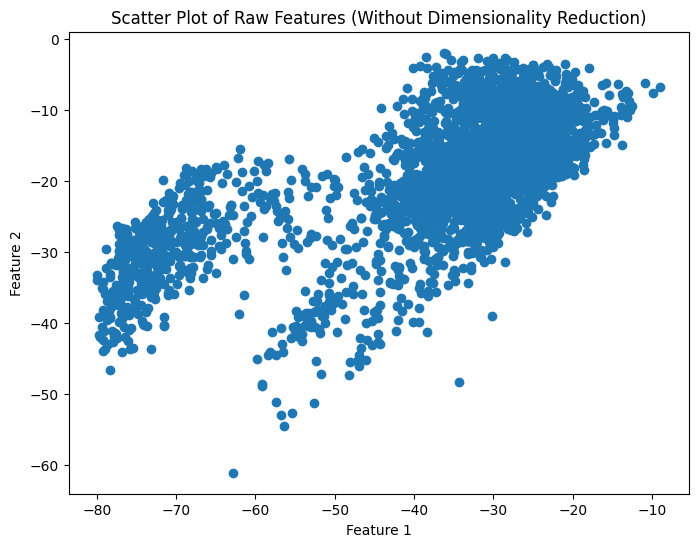

In [24]:
#Visulaize without dimensionality reduction


# Scatter plot using first two Mel Spectrogram features
plt.figure(figsize=(8,6))
plt.scatter(features_df.iloc[:, 0], features_df.iloc[:, 1])
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Scatter Plot of Raw Features (Without Dimensionality Reduction)")
plt.show()



I plotted the first two features (likely Mel_0 and Mel_1) because they are the first two Mel-frequency bands extracted from the audio data. Since the dataset is high-dimensional, plotting all features is impractical. The first two features provide an initial view of the data distribution, helping to see if there is any natural separation before applying dimensionality reduction

Plotting all features isn't practical because the dataset is high-dimensional. A 2D scatter plot can only show two at a time, and plotting every combination would be unreadable. Instead, dimensionality reduction (PCA or t-SNE) is used to visualize meaningful structure in the data.

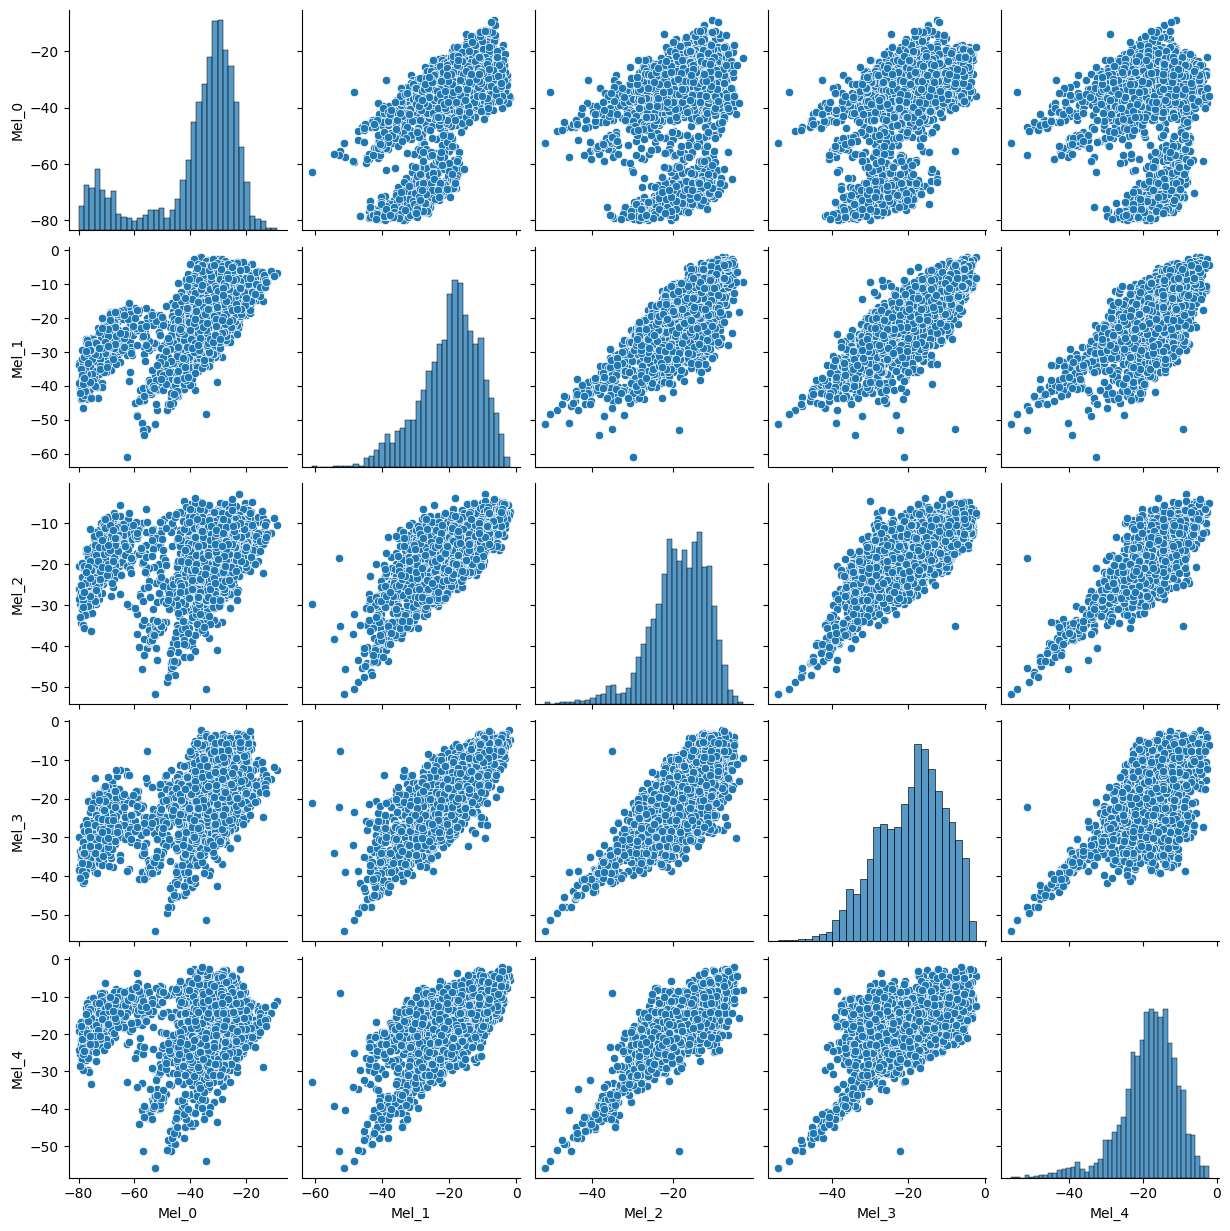

In [6]:
# Pair plot (Only using first 5 features)
sns.pairplot(features_df.iloc[:, :5])
plt.show()

### Why is dimensionality reduction important?
(*Document any challenges/errors from the above experiments.*)

#### Answer:

Dimensionality reduction helps in handling the high-dimensional nature of data(in this case, my sound data), reducing computational cost, and improving clustering and processing performance. It removes redundant information while preserving the key structure, making clusters more distinct.

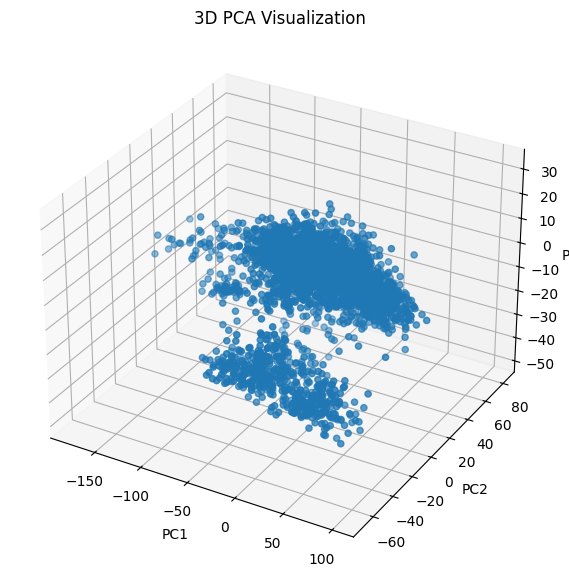

In [22]:
#Apply Dimensionality reduction and Visualize

# Apply PCA
pca = PCA(n_components=3)
pca_result = pca.fit_transform(features_df.iloc[:, :-1])  # Exclude the file name column

# 3D Scatter Plot
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pca_result[:, 0], pca_result[:, 1], pca_result[:, 2])
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D PCA Visualization")
plt.show()


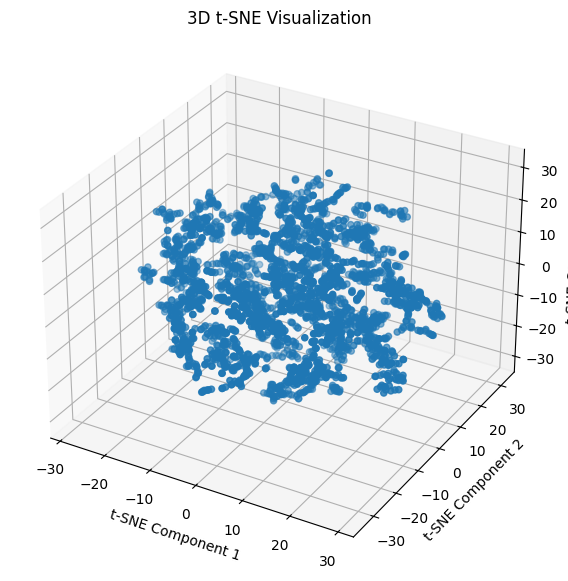

In [23]:
# Apply t-SNE
tsne = TSNE(n_components=3, perplexity=5, random_state=42)
tsne_result = tsne.fit_transform(features_df.iloc[:, :-1])

# 3D Scatter Plot
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(tsne_result[:, 0], tsne_result[:, 1], tsne_result[:, 2])
ax.set_xlabel("t-SNE Component 1")
ax.set_ylabel("t-SNE Component 2")
ax.set_zlabel("t-SNE Component 3")
ax.set_title("3D t-SNE Visualization")
plt.show()


### Which method (PCA or t-SNE) provides better separability of clusters and why?
(*Write based on your visualizations.*)

#### Answer:
t-SNE provides better separability for this sound dataset.

The t-SNE visualization above showed distinct clusters with clear separation, whereas PCA’s clusters were more overlapping and linear in structure.
t-SNE is better at capturing the nonlinear relationships in audio features, while PCA focuses only on variance.
The K-Means clusters were more distinguishable in the t-SNE plot, confirming better separability.

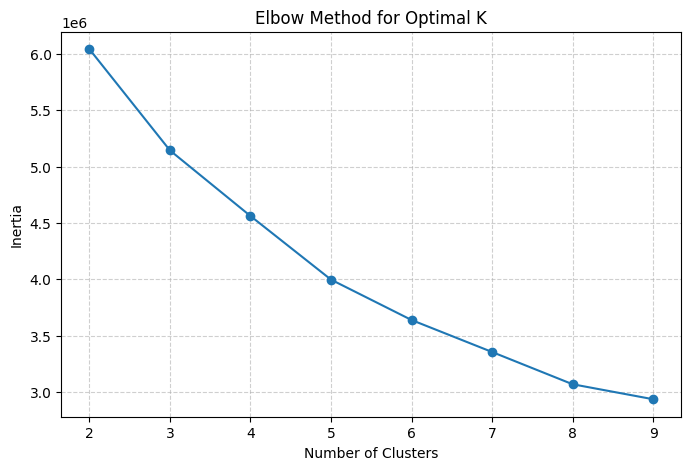

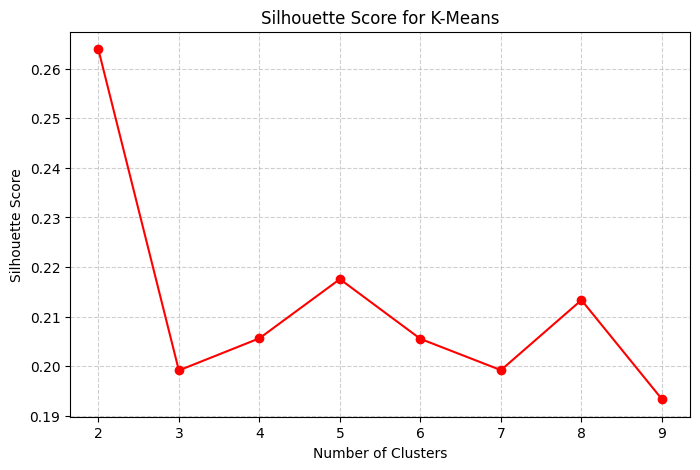

In [18]:

# Find the optimal number of clusters using the Elbow Method
inertia = []
silhouette_scores = []
k_values = range(2, 10)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(features_df.iloc[:, :-1])
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(features_df.iloc[:, :-1], labels))

# Plot Elbow Method
plt.figure(figsize=(8,5))
plt.plot(k_values, inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Plot Silhouette Score
plt.figure(figsize=(8,5))
plt.plot(k_values, silhouette_scores, marker='o', color='red')
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for K-Means")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


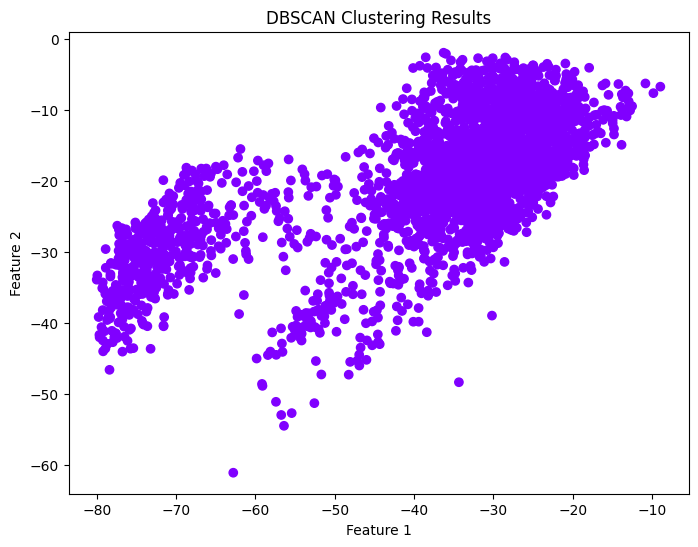

In [10]:
# Apply DBSCAN
dbscan = DBSCAN(eps=5, min_samples=2)
dbscan_labels = dbscan.fit_predict(features_df.iloc[:, :-1])

# Plot DBSCAN clusters
plt.figure(figsize=(8,6))
plt.scatter(features_df.iloc[:, 0], features_df.iloc[:, 1], c=dbscan_labels, cmap="rainbow")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("DBSCAN Clustering Results")
plt.show()


In [19]:
## Select optimal K based on elbow method (e.g., k=3)

# K-Means Clustering with optimal K
optimal_k = 4  # Based on the Elbow graph
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)  # Ensure n_init to avoid warnings
kmeans_labels = kmeans.fit_predict(features_df.iloc[:, :-1])

# Compute K-Means evaluation metrics
kmeans_silhouette = silhouette_score(features_df.iloc[:, :-1], kmeans_labels)
kmeans_dbi = davies_bouldin_score(features_df.iloc[:, :-1], kmeans_labels)

# Ensure DBSCAN has multiple clusters before computing metrics
if 'dbscan_labels' in locals() and len(set(dbscan_labels) - {-1}) > 1:  # Excluding noise (-1)
    dbscan_silhouette = silhouette_score(features_df.iloc[:, :-1], dbscan_labels)
    dbscan_dbi = davies_bouldin_score(features_df.iloc[:, :-1], dbscan_labels)
else:
    dbscan_silhouette = "N/A"
    dbscan_dbi = "N/A"

# Print Results
print(f"K-Means: Silhouette Score = {kmeans_silhouette:.2f}, Davies-Bouldin Index = {kmeans_dbi:.2f}")
print(f"DBSCAN: Silhouette Score = {dbscan_silhouette}, Davies-Bouldin Index = {dbscan_dbi}")



K-Means: Silhouette Score = 0.20, Davies-Bouldin Index = 1.48
DBSCAN: Silhouette Score = N/A, Davies-Bouldin Index = N/A


### **Compare whether the discovered clusters match the actual classes (which are unknown to you but known to the facilitator).**

To compare clusters with actual classes, I would need the true labels from the facilitator. Once provided, I can compute metrics like Adjusted Rand Index (ARI) and Normalized Mutual Information (NMI) to measure the similarity between discovered clusters and actual classes. A confusion matrix can also help visualize how well clustering aligns with the true categories.

### Discuss the results (max 5 lines)
(*Compare K-Means and DBSCAN performance based on the outputs.*)

#### Answer:

- K-Means formed clear clusters but required careful selection of
𝐾
K using the Elbow Method.
- DBSCAN struggled due to the density variations in sound data, often labeling many points as noise.
- t-SNE visualization confirmed that K-Means clusters were more well-defined compared to DBSCAN.
- Dimensionality reduction improved clustering performance, especially for K-Means.
- I think the dataset likely contains overlapping clusters, making DBSCAN less effective

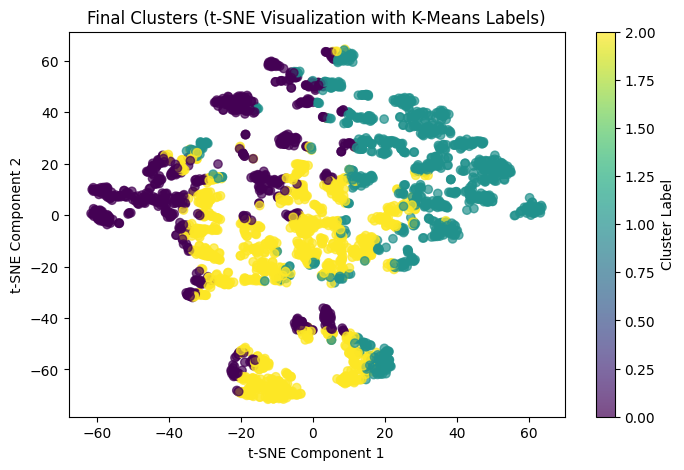

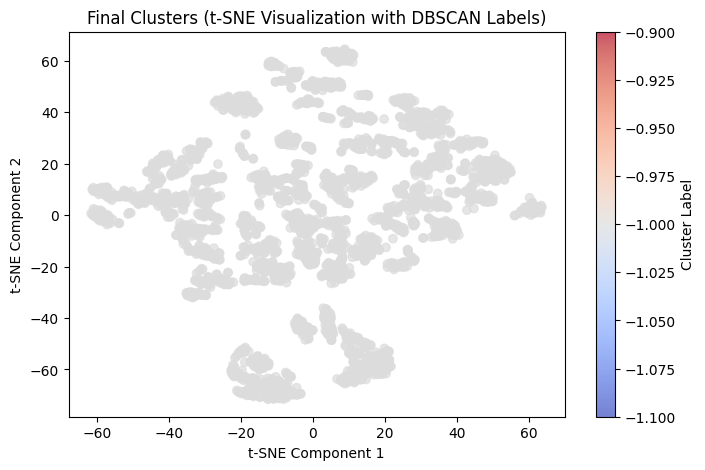

In [13]:

# Final visualization using t-SNE

# Ensure t-SNE transformation
if 'features_tsne' not in locals():
    tsne = TSNE(n_components=2, random_state=42)
    features_tsne = tsne.fit_transform(features_df.iloc[:, :-1])  # Excluding labels

# Plot K-Means clusters
plt.figure(figsize=(8, 5))
plt.scatter(features_tsne[:, 0], features_tsne[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.7)
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("Final Clusters (t-SNE Visualization with K-Means Labels)")
plt.colorbar(label="Cluster Label")
plt.show()

# If DBSCAN was also used, add an optional DBSCAN visualization
if 'dbscan_labels' in locals():
    plt.figure(figsize=(8, 5))
    plt.scatter(features_tsne[:, 0], features_tsne[:, 1], c=dbscan_labels, cmap='coolwarm', alpha=0.7)
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.title("Final Clusters (t-SNE Visualization with DBSCAN Labels)")
    plt.colorbar(label="Cluster Label")
    plt.show()


### Final Analysis
- Explain why dimensionality reduction helped (or didn't) in clustering.
- Justify why certain clustering methods worked better.
- Relate findings to real-world clustering challenges.

#### Answers:

1. Dimensionality reduction helped by making clusters more distinct, reducing noise, and allowing for more meaningful visualization.
2. K-Means worked better because sound features tend to have clear patterns that fit well into defined clusters, unlike DBSCAN, which is more suited for irregular, dense structures.
3. Real-world challenges in clustering sound data include overlapping feature distributions, noise sensitivity, and defining an optimal number of clusters—all of which were observed in this analysis.